# Seaborn - Statistical Data Visualization

**What:** A high-level library built on matplotlib that makes beautiful statistical charts with less code. Integrates directly with pandas DataFrames.

**When to use:**
- Exploring relationships between variables (scatter, regression, pair plots)
- Analyzing distributions (histplot, KDE, violin, box plots)
- Finding correlations in data (heatmaps)
- Comparing categories (bar, count, strip, swarm plots)
- Creating publication-ready plots with built-in themes and color palettes

**Key concept:** Pass a DataFrame and column names directly — seaborn handles the rest. Use `hue` parameter to add color grouping.

In [ ]:
# Install dependencies (run once)
!uv add seaborn matplotlib pandas numpy

In [1]:
# 1. Setup
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set theme
sns.set_theme(style="whitegrid")

print("Seaborn ready!")

Seaborn ready!


In [ ]:
# 2. Create Sample Dataset
np.random.seed(42)

df = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie", "Diana", "Eve"] * 20,
    "department": np.random.choice(["Engineering", "Sales", "Marketing", "HR"], 100),
    "salary": np.random.normal(60000, 15000, 100).astype(int),
    "experience": np.random.randint(1, 20, 100),
    "performance": np.random.uniform(2.0, 5.0, 100).round(1),
    "age": np.random.randint(22, 55, 100),
})

print(df.head(10))

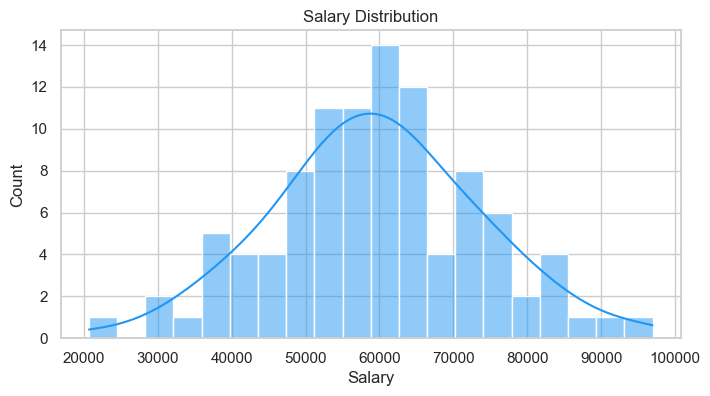

In [3]:
# 3. Histogram with KDE (Distribution Plot)
plt.figure(figsize=(8, 4))
sns.histplot(df["salary"], bins=20, kde=True, color="#2196F3")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

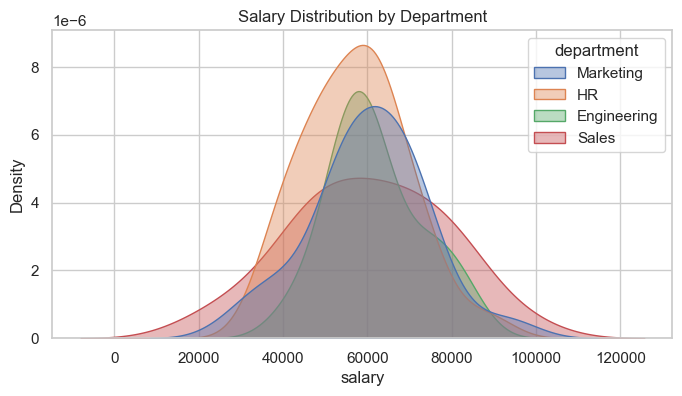

In [4]:
# 4. KDE Plot (Smooth Density Curve)
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="salary", hue="department", fill=True, alpha=0.4)
plt.title("Salary Distribution by Department")
plt.show()

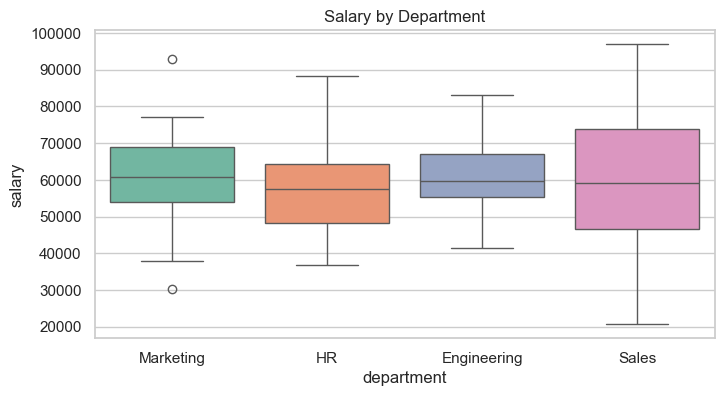

In [6]:
# 5. Box Plot (Outlier Detection)
plt.figure(figsize=(8, 4))
sns.boxplot(x="department", y="salary", data=df, hue="department", palette="Set2", legend=False)
plt.title("Salary by Department")
plt.show()

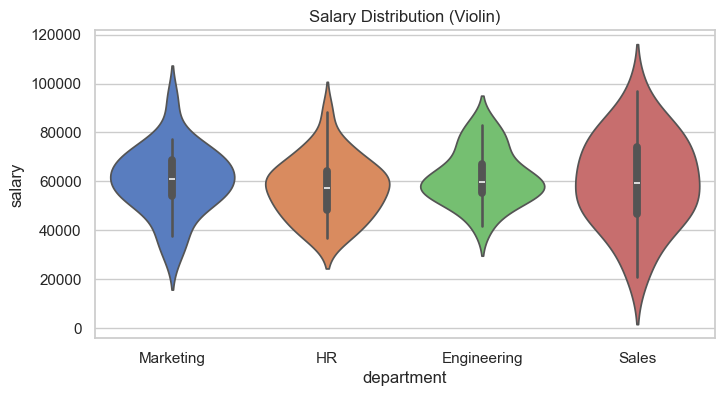

In [8]:
# 6. Violin Plot (Box + KDE Combined)
plt.figure(figsize=(8, 4))
sns.violinplot(x="department", y="salary", data=df, hue="department", palette="muted", inner="box", legend=False)
plt.title("Salary Distribution (Violin)")
plt.show()

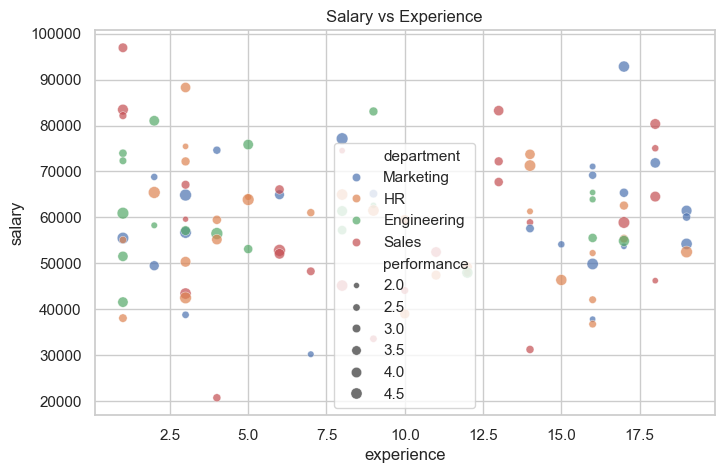

In [9]:
# 7. Scatter Plot with Hue
plt.figure(figsize=(8, 5))
sns.scatterplot(x="experience", y="salary", hue="department", size="performance",
                data=df, palette="deep", alpha=0.7)
plt.title("Salary vs Experience")
plt.show()

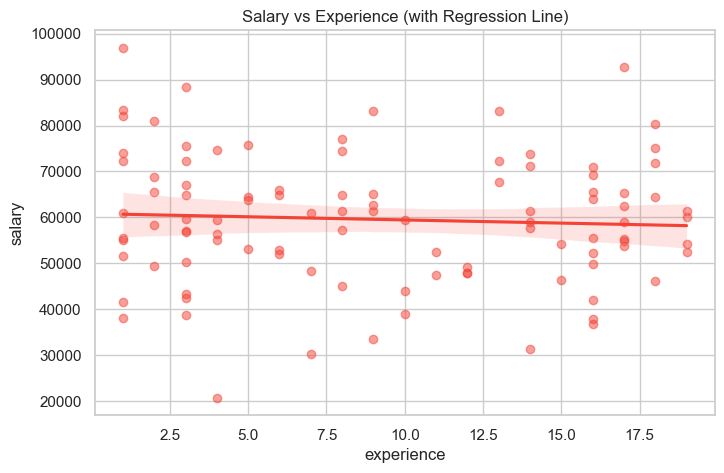

In [10]:
# 8. Regression Plot (Scatter + Trend Line)
plt.figure(figsize=(8, 5))
sns.regplot(x="experience", y="salary", data=df, scatter_kws={"alpha": 0.5}, color="#F44336")
plt.title("Salary vs Experience (with Regression Line)")
plt.show()

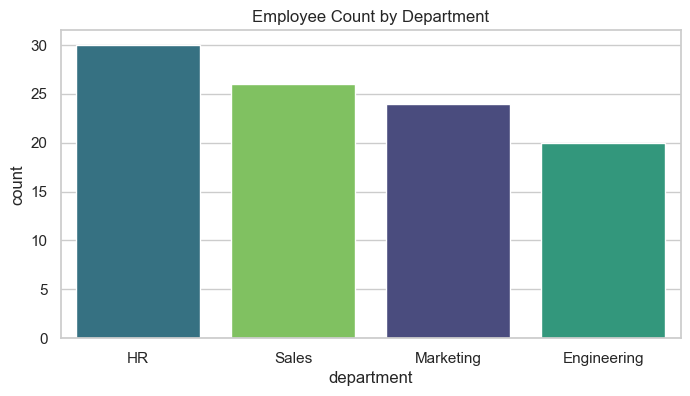

In [11]:
# 9. Count Plot (Category Counts)
plt.figure(figsize=(8, 4))
sns.countplot(x="department", data=df, hue="department", palette="viridis",
              order=df["department"].value_counts().index, legend=False)
plt.title("Employee Count by Department")
plt.show()

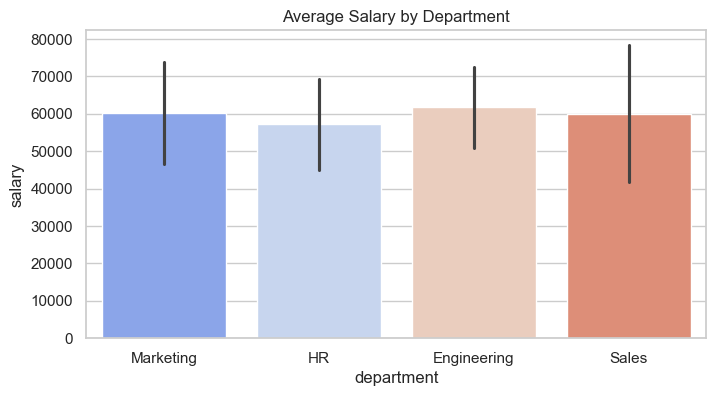

In [12]:
# 10. Bar Plot (Mean with Confidence Interval)
plt.figure(figsize=(8, 4))
sns.barplot(x="department", y="salary", data=df, hue="department", palette="coolwarm", errorbar="sd", legend=False)
plt.title("Average Salary by Department")
plt.show()

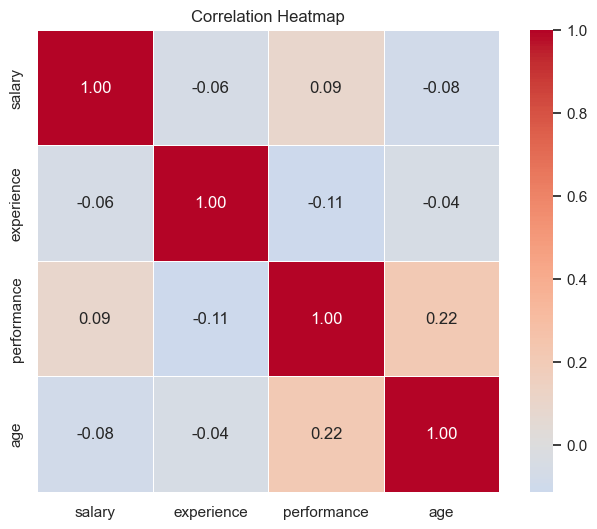

In [13]:
# 11. Heatmap (Correlation Matrix)
numeric_df = df[["salary", "experience", "performance", "age"]]
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.show()

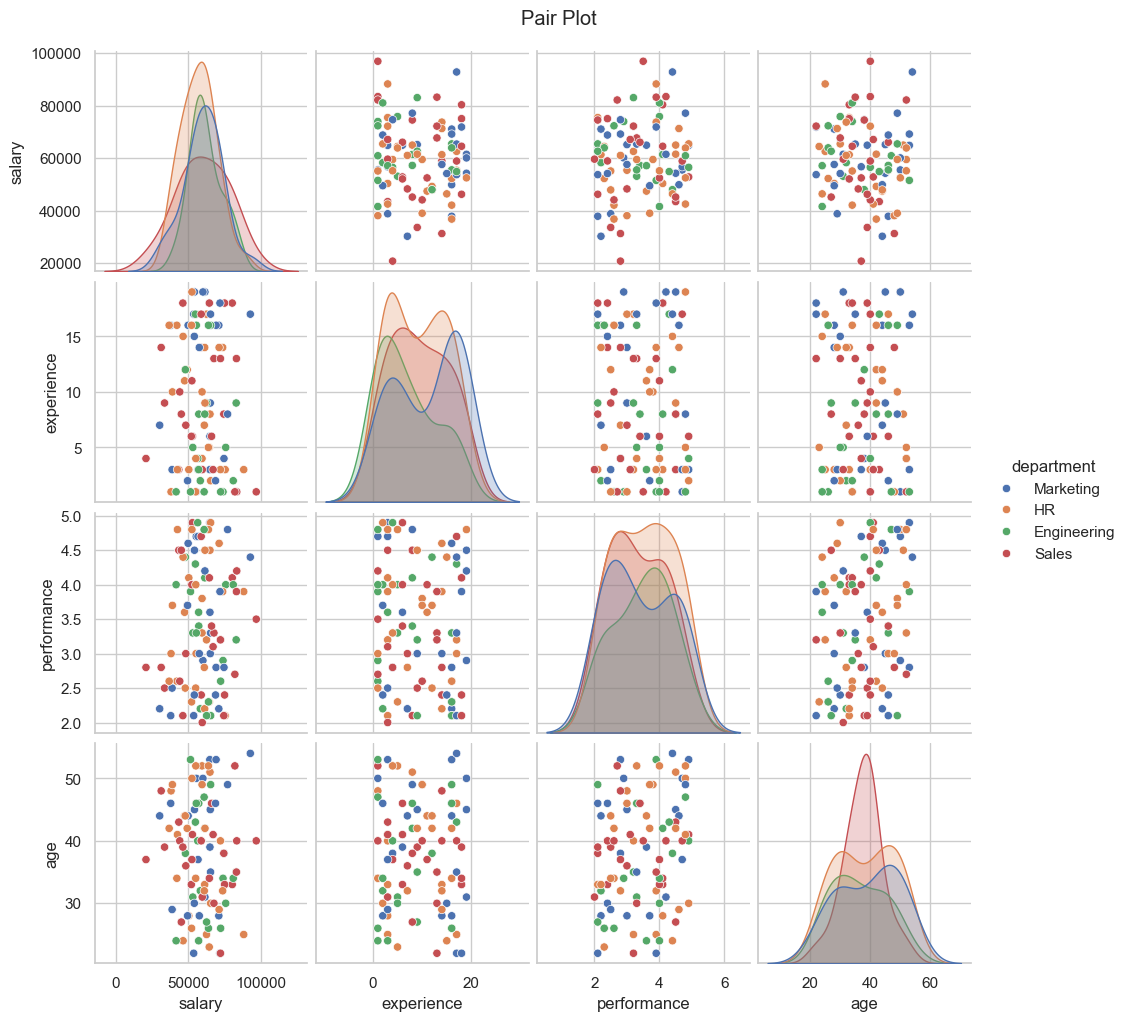

In [14]:
# 12. Pair Plot (All Variable Relationships)
sns.pairplot(df[["salary", "experience", "performance", "age", "department"]],
             hue="department", palette="deep", diag_kind="kde")
plt.suptitle("Pair Plot", y=1.02)
plt.show()

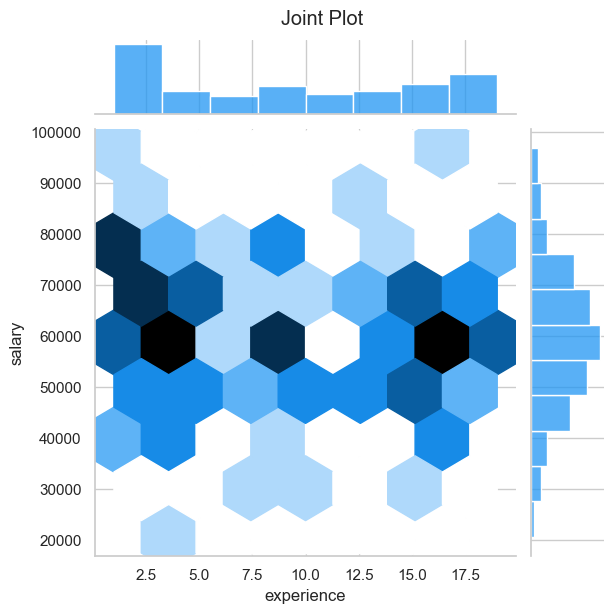

In [15]:
# 13. Joint Plot (Scatter + Distribution)
sns.jointplot(x="experience", y="salary", data=df, kind="hex", color="#2196F3")
plt.suptitle("Joint Plot", y=1.02)
plt.show()

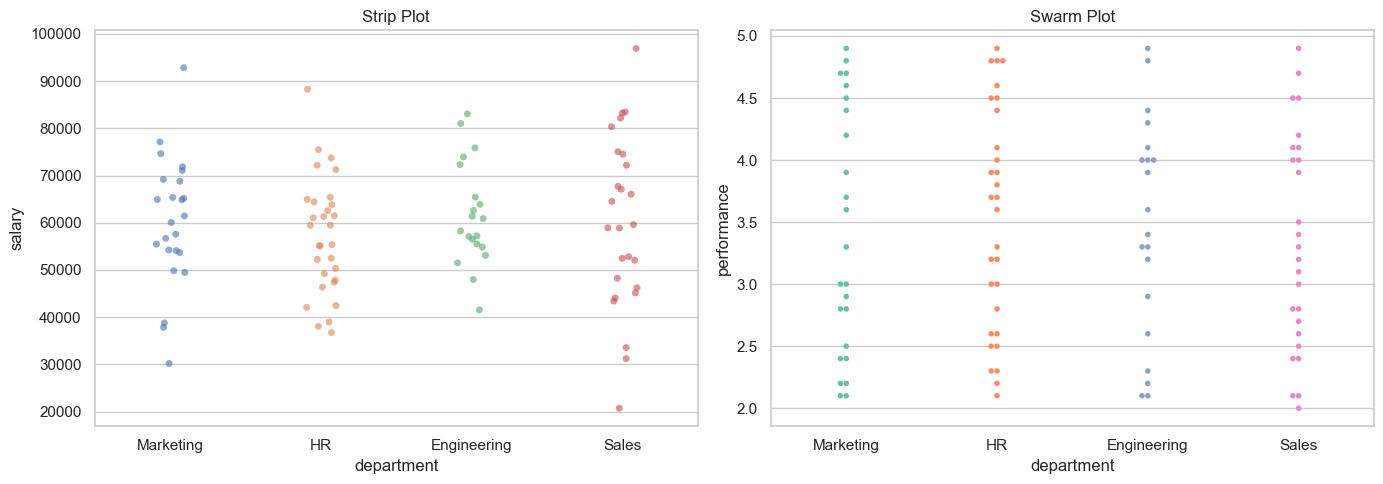

In [16]:
# 14. Strip Plot + Swarm Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.stripplot(x="department", y="salary", data=df, hue="department", ax=axes[0], alpha=0.6, jitter=True, legend=False)
axes[0].set_title("Strip Plot")

sns.swarmplot(x="department", y="performance", data=df, hue="department", ax=axes[1], palette="Set2", size=4, legend=False)
axes[1].set_title("Swarm Plot")

plt.tight_layout()
plt.show()

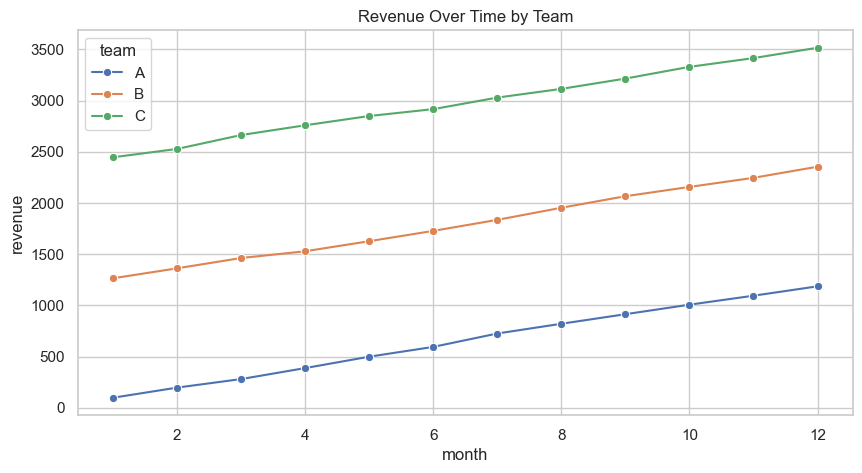

In [17]:
# 15. Line Plot with Confidence Band
time_df = pd.DataFrame({
    "month": list(range(1, 13)) * 3,
    "revenue": np.random.normal(100, 15, 36).cumsum(),
    "team": ["A"] * 12 + ["B"] * 12 + ["C"] * 12,
})

plt.figure(figsize=(10, 5))
sns.lineplot(x="month", y="revenue", hue="team", data=time_df, marker="o")
plt.title("Revenue Over Time by Team")
plt.show()

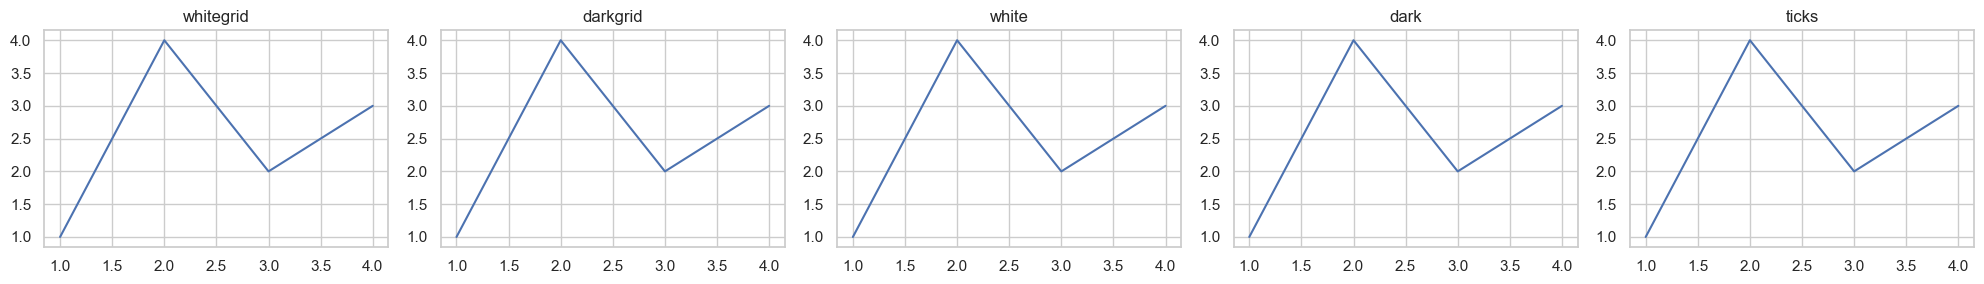

In [18]:
# 16. Available Themes
themes = ["whitegrid", "darkgrid", "white", "dark", "ticks"]

fig, axes = plt.subplots(1, 5, figsize=(20, 3))

for ax, theme in zip(axes, themes):
    sns.set_theme(style=theme)
    ax.plot([1, 2, 3, 4], [1, 4, 2, 3])
    ax.set_title(theme)

plt.tight_layout()
plt.show()

# Reset
sns.set_theme(style="whitegrid")

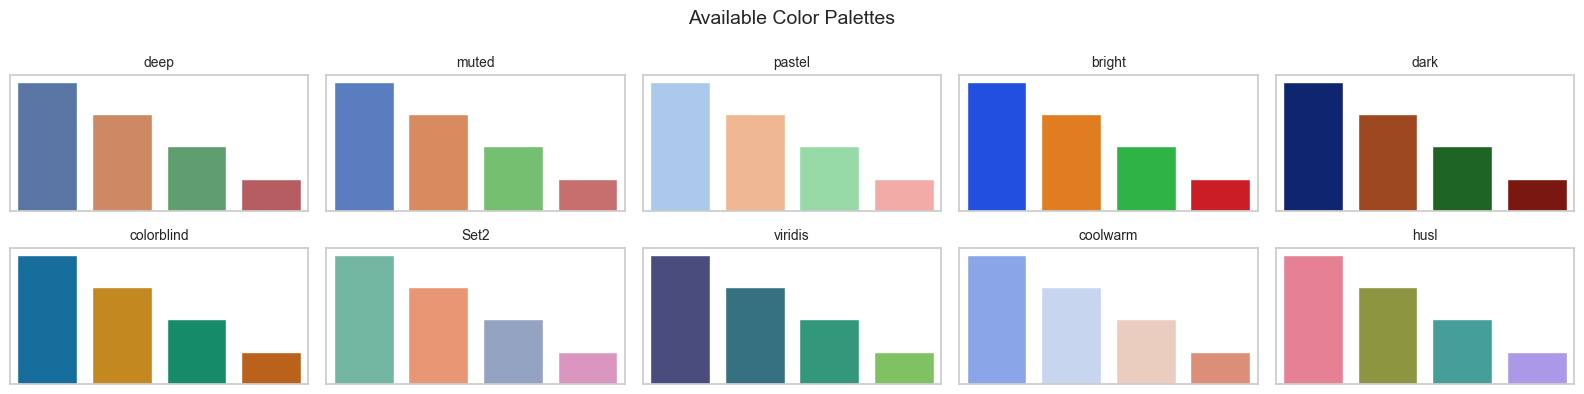

In [19]:
# 17. Color Palettes
palettes = ["deep", "muted", "pastel", "bright", "dark", "colorblind",
            "Set2", "viridis", "coolwarm", "husl"]

fig, axes = plt.subplots(2, 5, figsize=(16, 4))

labels = ["A", "B", "C", "D"]
values = [4, 3, 2, 1]

for ax, palette in zip(axes.flat, palettes):
    sns.barplot(x=labels, y=values, hue=labels, palette=palette, ax=ax, legend=False)
    ax.set_title(palette, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Available Color Palettes", fontsize=14)
plt.tight_layout()
plt.show()